<a href="https://colab.research.google.com/github/HafidzShahab/Data-Science_240401020180_AhmadHafidz/blob/main/pertemuan13_%5BAhmad_Hafidz%5D__%5B240401020180%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* **Nama** : Ahmad Hafidz
* **NIM** : 240401020180
* **Kelas** : IF 401

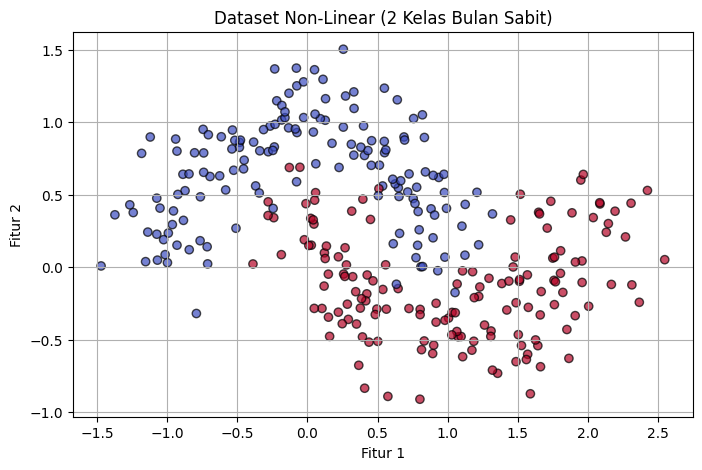

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 1. Generate dataset non-linear
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# 2. Visualisasi data
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.grid(True)
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Split data (80% training, 20% testing)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Bangun Arsitektur Model Sequential
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),  # Hidden layer 1 (16 neuron)
    Dense(8, activation='relu'),                     # Hidden layer 2 (8 neuron)
    Dense(1, activation='sigmoid')                   # Output layer (1 neuron untuk binari)
])

# 3. Compile Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Tampilkan Ringkasan Arsitektur
model.summary()

# 5. Proses Training (Latih Model)
history = model.fit(X_tr, y_tr,
                    epochs=30,
                    validation_split=0.2,
                    verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5104 - loss: 0.6797 - val_accuracy: 0.6042 - val_loss: 0.6440
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6146 - loss: 0.6583 - val_accuracy: 0.7292 - val_loss: 0.6277
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7552 - loss: 0.6387 - val_accuracy: 0.7708 - val_loss: 0.6122
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7760 - loss: 0.6215 - val_accuracy: 0.8750 - val_loss: 0.5981
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8333 - loss: 0.6056 - val_accuracy: 0.8750 - val_loss: 0.5844
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8333 - loss: 0.5906 - val_accuracy: 0.8750 - val_loss: 0.5709
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8385 - loss: 0.5768 - val_accuracy: 0.8958 - val_loss: 0.5568
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8542 - loss: 0.5630 - val_accuracy: 0.8958 - val_loss: 0.5426


=== HASIL EVALUASI MODEL ===
Loss pada data uji   : 0.269
Akurasi pada data uji: 0.917



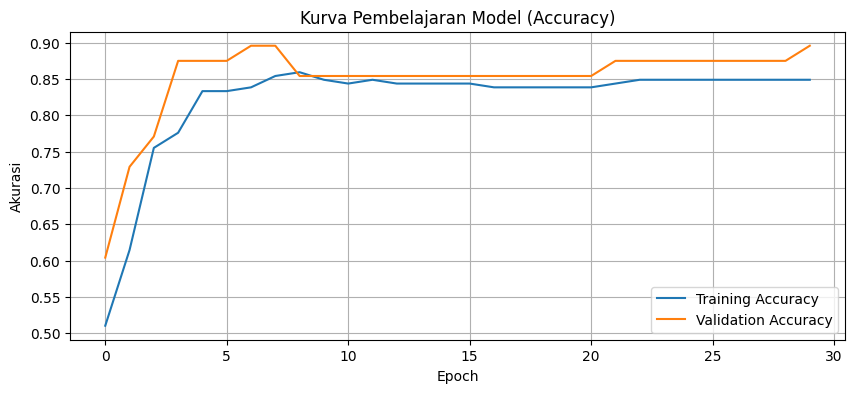

In [3]:
# 1. Evaluasi performa akhir pada data uji (test set)
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'=== HASIL EVALUASI MODEL ===')
print(f'Loss pada data uji   : {loss:.3f}')
print(f'Akurasi pada data uji: {acc:.3f}\n')

# 2. Plot Kurva Akurasi
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model (Accuracy)')
plt.grid(True)
plt.show()

In [10]:
# 40 ulasan produk sintetis berbahasa Indonesia
ulasan = [
    'Barangnya bagus banget, pengiriman cepat', 'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi', 'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas', 'Buruk sekali, tidak sesuai ekspektasi',
    'Respon penjual sangat cepat dan ramah', 'Pengemasan kurang aman, pecah di jalan',
    'Bahan tebal dan nyaman digunakan', 'Kapok belanja di sini, pelayanan buruk',
    'Sesuai pesanan, packing rapi aman', 'Barang tiruan, kualitas sangat rendah',
    'Harga murah tapi barang tidak murahan', 'Ukuran kekecilan, tidak sesuai dengan tabel',
    'Sangat membantu, kurir juga ramah', 'Tidak berfungsi dengan baik, kecewa berat',
    'Pengiriman kilat, barang berfungsi normal', 'Warna pudar tidak seperti di gambar resmi',
    'Produk original, segel masih utuh', 'Jahitannya tidak rapi, banyak yang lepas',
    'Mantap betul, anak saya suka sekali', 'Sangat lambat pengirimannya, sebulan baru sampai',
    'Kualitas bintang lima, harga kaki lima', 'Material plastik murah dan gampang patah',
    'Terima kasih, produk bekerja dengan baik', 'Deskripsi produk sangat menyesatkan pembeli',
    'Bonusnya banyak, terima kasih seller', 'Aplikasi sering error, tidak bisa dipakai',
    'Desain elegan dan mewah saat dipakai', 'Sangat mengecewakan, tidak ada garansi resmi',
    'Top banget, tidak menyesal beli di sini', 'Barang datang dalam keadaan cacat tergores',
    'Sesuai dengan ekspektasi saya, puas!', 'Pelayanan toko ini sangat tidak sopan',
    'Sudah langganan dan selalu puas belakangan ini', 'Fungsinya tidak jelas, membuang uang saja',
    'Pengiriman aman pakai bubble wrap tebal', 'Bau kimianya menyengat sekali, tidak nyaman',
    'Sangat direkomendasikan untuk dibeli', 'Barang hilang satu komponen saat dibuka'
]

# 1 = positif, 0 = negatif
label = [
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0
]

print(f"Jumlah ulasan: {len(ulasan)}")
print(f"Jumlah label : {len(label)}")

Jumlah ulasan: 40
Jumlah label : 40


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Inisialisasi TF-IDF
tfidf = TfidfVectorizer()

# 2. Transformasi teks menjadi matriks angka
X_text = tfidf.fit_transform(ulasan)

# 3. Eksplorasi token/kata unik
print(f'=== EKSPLORASI FITUR TEKS ===')
print('Jumlah kata unik di seluruh dokumen:', len(tfidf.get_feature_names_out()))
print('15 Contoh kata pertama hasil tokenisasi:\n', tfidf.get_feature_names_out()[:15])

=== EKSPLORASI FITUR TEKS ===
Jumlah kata unik di seluruh dokumen: 143
15 Contoh kata pertama hasil tokenisasi:
 ['ada' 'akan' 'aman' 'anak' 'aplikasi' 'bagus' 'bahan' 'baik' 'banget'
 'banyak' 'barang' 'barangnya' 'baru' 'bau' 'bekerja']


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Split data teks (80% training, 20% testing)
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_text, label, test_size=0.2, random_state=42)

# 2. Inisialisasi dan Pelatihan Model Klasifikasi (Logistic Regression)
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

# 3. Hitung Akurasi Data Uji
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model klasifikasi sentimen: {akurasi:.3f}\n')

# 4. Uji Coba Prediksi dengan Kalimat Baru diluar Dataset
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
X_baru = tfidf.transform(kalimat_baru)
pred = model_sentimen.predict(X_baru)

print(f'=== UJI COBA PREDIKSI ===')
print(f'Teks Input : "{kalimat_baru[0]}"')
print(f'Hasil Prediksi Sentimen : {"POSITIF" if pred[0] == 1 else "NEGATIF"}')

Akurasi model klasifikasi sentimen: 0.625

=== UJI COBA PREDIKSI ===
Teks Input : "Pelayanan sangat memuaskan dan ramah"
Hasil Prediksi Sentimen : POSITIF


KESIMPULAN : Modul ini memberikan pemahaman dasar mengenai transisi dari Machine Learning klasik ke Deep Learning, di mana model kini mampu mengekstraksi fitur secara otomatis langsung dari data mentah melalui arsitektur Jaringan Saraf Tiruan (ANN). Proses pembelajaran model dilakukan secara iteratif dalam hitungan epoch, memanfaatkan forward pass untuk memprediksi data dan backpropagation untuk memperbarui bobot berdasarkan tingkat error yang dihasilkan. Selain itu, modul ini memperkenalkan dasar NLP melalui teknik TF-IDF, yang menyempurnakan metode Bag-of-Words dengan memberikan pembobotan lebih tinggi pada kata-kata yang unik dan khas dalam suatu dokumen. Melalui aktivitas hands-on, mahasiswa berhasil mengimplementasikan Keras untuk menyelesaikan klasifikasi data non-linear serta menerapkan Logistic Regression berbasis TF-IDF untuk melakukan analisis sentimen sederhana secara efisien.